<font size = 10>Autograd</font>

# Local run setup: Windows vs Mac (CUDA vs MPS)

Set the parameter below to match your machine:

- **Windows** → prefers **CUDA** (NVIDIA GPU) if available  
- **Mac** → prefers **MPS** (Apple Silicon GPU) if available  

If the preferred accelerator is not available, the notebook will **fall back to CPU**.

This notebook includes plotting and scalar-printing from tensors, so the helpers `to_numpy(...)` and `to_scalar(...)` safely move tensors to CPU when needed.


In [15]:
# ===== Platform / device selector =====
# Set this to: "Windows" or "Mac"
PLATFORM = "Mac"

# Set to False if you want to force CPU even when a GPU backend is available
USE_ACCELERATOR = True

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt

def pick_device(platform_choice: str, use_accelerator: bool = True) -> torch.device:
    if not use_accelerator:
        return torch.device("cpu")

    p = platform_choice.strip().lower()

    if p.startswith("mac"):
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")

    if p.startswith("win"):
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")

    raise ValueError('PLATFORM must be "Windows" or "Mac".')

DEVICE = pick_device(PLATFORM, USE_ACCELERATOR)

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def to_scalar(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().item()
    return float(x)

print(f"PLATFORM = {PLATFORM}")
print(f"Selected DEVICE = {DEVICE}")

if DEVICE.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
elif DEVICE.type == "mps":
    print("Using Apple Silicon GPU via MPS")
else:
    print("Using CPU")


PLATFORM = Mac
Selected DEVICE = mps
Using Apple Silicon GPU via MPS


# PyTorch Autograd

In [16]:
# Imports are handled in the setup cell above.

## Aurograd example

Compute derivatives $\frac {\partial y}{\partial a}$, $\frac {\partial y}{\partial b}$ and $\frac {\partial y}{\partial c}$ of the function $y(x, a,b,c)$ at specific point $x=0.76$

$$\large y(x) =  a^2 \cdot x + cos(b \cdot x) + c \cdot x$$
Analytical derivation: 
$$\large \frac {\partial y}{\partial a} =2 \cdot a \cdot x $$
$$\large \frac {\partial y}{\partial b} =-x \cdot sin(b \cdot x) $$
$$\large \frac {\partial y}{\partial c} =x $$

In [18]:
a = torch.tensor(-1.0, dtype=torch.float32, device=DEVICE, requires_grad=True)
b = torch.tensor(3.0, dtype=torch.float32, device=DEVICE, requires_grad=True)
c = torch.tensor(5.0, dtype=torch.float32, device=DEVICE, requires_grad=True)

def eq(x, a, b, c):
    return a**2 * x + torch.cos(b * x) + c * x

x = 0.76
y = eq(x, a, b, c)
y.backward()  # computes derivatives of y with respect to a, b, and c at x

print("Autograd:")
print(a.grad, b.grad, c.grad, sep = "\n")

print("Manual:")
print(f"{to_scalar(2 * a * x):0.4f}")
print(f"{to_scalar(-x * torch.sin(b * x)):0.4f}")
print(f"{float(x):0.4f}")


Autograd:
tensor(-1.5200, device='mps:0')
tensor(-0.5767, device='mps:0')
tensor(0.7600, device='mps:0')
Manual:
-1.5200
-0.5767
0.7600


## Integrate Autograd into the Gradient Descent Algorithm
### Define inputs and outputs for the model

In [ ]:
t_c = torch.tensor(
    [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0],
    dtype=torch.float32,
    device=DEVICE
)
t_u = torch.tensor(
    [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4],
    dtype=torch.float32,
    device=DEVICE
)

print(f"t_c device: {t_c.device}, t_u device: {t_u.device}")


t_c device: mps:0, t_u device: mps:0


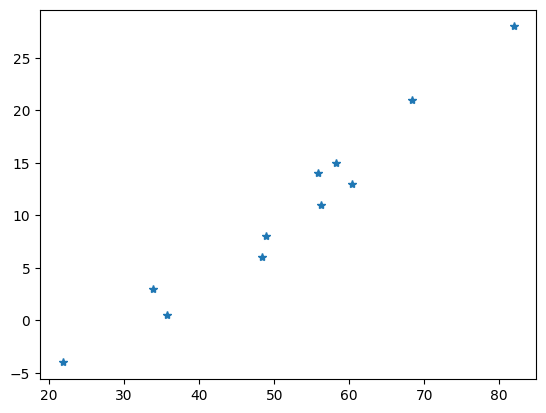

In [ ]:
plt.plot(to_numpy(t_u), to_numpy(t_c), '*')

In [ ]:
def model(t_u, w, b):
    return w * t_u + b

def loss_fn(t_p, t_c):
    return torch.mean(torch.square(t_p-t_c))


Alternatively, one could define: 
```
def loss_fn(t_u,w,b, t_c):
    return torch.mean(torch.square( model(t_u, w, b)-t_c)) 
```

## Implement the model
Note that gradients of the loss function <br> w.r.t. $w$ and $b$ for the given data ($t_c$ and $t_u$) <br> are computed automatically<br>
$$\large L( x, y, \boldsymbol  w, \boldsymbol  b ) = \frac {1}{N} \sum {  ( (\boldsymbol w \cdot x + \boldsymbol b) -y)^2 }$$
- $\large x \longleftrightarrow t_u $
- $\large y \longleftrightarrow t_c $

Compute: 
$$\large \frac {\partial L( t_u, t_c, \boldsymbol  w, \boldsymbol  b ) }{\partial \boldsymbol w},   
\frac {\partial L( t_u, t_c, \boldsymbol  w, \boldsymbol  b ) }{\partial \boldsymbol b}$$


In [19]:
# model parameters (w, b)
params = torch.tensor([1.0, 0.0], dtype=torch.float32, device=DEVICE, requires_grad=True)  
# just compute loss
loss = loss_fn(model(t_u, *params), t_c)  
# compute gradients
loss.backward()  
print("loss = ", loss)
print("grad = ", params.grad)



loss =  tensor(1763.8846, device='mps:0', grad_fn=<MeanBackward0>)
grad =  tensor([4517.2964,   82.6000], device='mps:0')


<img src="Screenshot_gradients.png"></img> 

- calling <code>tensor.backward()</code> computes gradients with respect to all leafs.<br>
- These gradients accumulate at the leafs: every call adds newly computed gradients to the stored values.<br>
- Make sure to zero gradients at the *leafs* before calling <code>tensor.backward()</code>: <code>params.grad.zero_()</code><br>
- <code>with torch.no_grad():</code> - defines block within which computations are not added to the computational graph (e.g. for model validation). 

e.g. Accumulation of gradients

In [ ]:
for i in range(10): 
    loss = loss_fn( model(t_u, *params) , t_c)
    loss.backward() 
    print(params.grad)

tensor([9034.5928,  165.2000], device='mps:0')
tensor([13551.8887,   247.8000], device='mps:0')
tensor([18069.1855,   330.4000], device='mps:0')
tensor([22586.4824,   413.0000], device='mps:0')
tensor([27103.7793,   495.6000], device='mps:0')
tensor([31621.0762,   578.2001], device='mps:0')
tensor([36138.3711,   660.8000], device='mps:0')
tensor([40655.6680,   743.4000], device='mps:0')
tensor([45172.9648,   826.0000], device='mps:0')
tensor([49690.2617,   908.6000], device='mps:0')


In [ ]:
for i in range(10): 
    params.grad.zero_() # zero gradeints before computation!
    loss = loss_fn( model(t_u, *params) , t_c)
    loss.backward() 
    print(params.grad)

tensor([4517.2964,   82.6000], device='mps:0')
tensor([4517.2964,   82.6000], device='mps:0')
tensor([4517.2964,   82.6000], device='mps:0')
tensor([4517.2964,   82.6000], device='mps:0')
tensor([4517.2964,   82.6000], device='mps:0')
tensor([4517.2964,   82.6000], device='mps:0')
tensor([4517.2964,   82.6000], device='mps:0')
tensor([4517.2964,   82.6000], device='mps:0')
tensor([4517.2964,   82.6000], device='mps:0')
tensor([4517.2964,   82.6000], device='mps:0')


## Implement the Training Loop
The training loop uses gradients 
$$ \frac {\partial L( t_u, t_c, \boldsymbol  w, \boldsymbol  b ) }{\partial \boldsymbol w},   
\frac {\partial L( t_u, t_c, \boldsymbol  w, \boldsymbol  b ) }{\partial \boldsymbol b}$$ 
to update $\boldsymbol w$ and $\boldsymbol b$
<br>
$$\boldsymbol  w \leftarrow \boldsymbol  w - lr \cdot \frac {\partial L( t_u, t_c, \boldsymbol  w, \boldsymbol  b )}{\partial 
\boldsymbol w}$$
$$\boldsymbol  b \leftarrow \boldsymbol  b - lr \cdot \frac {\partial L( t_u, t_c, \boldsymbol  w, \boldsymbol  b )}{\partial \boldsymbol b}$$

In [ ]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):

        t_p = model(t_u, *params)  # compute model predictions
        loss = loss_fn(t_p, t_c)   # compute loss
        loss.backward()            # compute gradients

        with torch.no_grad():      # do not store the following in the computation graph
            params -= learning_rate * params.grad

        params.grad.zero_()        # zero gradients before computing them again

        if epoch % 500 == 0:
            print("Epoch %d, Loss %f" % (epoch, to_scalar(loss)))
    return params


## Run the Model

### Accelerate conversion with data normalization
$ \large t_u \rightarrow 0.1 \cdot t_u$

In [ ]:
training_loop(
    n_epochs=5000,
    learning_rate=1e-2,
    params=torch.tensor([1.0, 0.0], dtype=torch.float32, device=DEVICE, requires_grad=True),
    t_u=0.1 * t_u,  # normalize variables
    t_c=t_c,
)

Epoch 500, Loss 7.860118
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957698
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927680
Epoch 4500, Loss 2.927651
Epoch 5000, Loss 2.927648


tensor([  5.3671, -17.3012], device='mps:0', requires_grad=True)

Properly normalize inputs: 
$$ \large t_u \rightarrow \frac {t_u-mean(t_u)} {std(t_u)}$$

In [ ]:
params = training_loop(
    n_epochs=5000,
    learning_rate=1e-2,
    params=torch.tensor([1.0, 0.0], dtype=torch.float32, device=DEVICE, requires_grad=True),
    t_u=(t_u - t_u.mean()) / t_u.std(),  # use proper variable normalization
    t_c=t_c,
)
params


Epoch 500, Loss 2.927646
Epoch 1000, Loss 2.927646
Epoch 1500, Loss 2.927646
Epoch 2000, Loss 2.927646
Epoch 2500, Loss 2.927646
Epoch 3000, Loss 2.927646
Epoch 3500, Loss 2.927646
Epoch 4000, Loss 2.927646
Epoch 4500, Loss 2.927646
Epoch 5000, Loss 2.927646


tensor([ 9.0349, 10.5000], device='mps:0', requires_grad=True)

Translate model parameters: 
$$ w-> \frac {w}{std(t_u)} $$ 
$$ b -> b + \frac {mean(t_u)}{std(t_u)} $$ 
Expected: $(t_u - 32)\cdot \frac {5}{9} = 0.556 \cdot t_u-17.778$

In [20]:
# Translate parameters learned on standardized input
# back to the original t_u scale

translated_w = params[0] / t_u.std()
translated_b = params[1] - params[0] * t_u.mean() / t_u.std()

print("translated_w =", to_scalar(translated_w))
print("translated_b =", to_scalar(translated_b))

to_scalar(translated_w), to_scalar(translated_b)

translated_w = 0.059410881251096725
translated_b = -3.077483654022217


(0.059410881251096725, -3.077483654022217)